#**Generative Adverserial Networks**

In [70]:
import torch
import torchvision
from torchvision.transforms import ToTensor, Normalize, Compose
from torchvision.datasets import MNIST


mnist = MNIST(root = 'data',
              train = True,
              download=True,
              transform = Compose([ToTensor(), Normalize(mean=(0.5,), std=(0.5, ))]))

* Define the problem statement
* Load the data (with transforms and normalization)
  * Denormalize for visual inspection of samples
* Define the Discriminator network
  * Study the activation function: Leaky ReLU
* Define the Generator network
  * Explain the output activation function: TanH
  * Look at some sample outputs
* Define losses, optimizers and helper functions for training
  * For discriminator
  * For generator
* Train the model
  * Save intermediate generated images to file
* Look at some outputs
* Save the models

In [71]:
mnist[0]

(tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.000

In [72]:
img, label = mnist[0]
print('Label: ', label)
print(img[:,10:15,10:15])
torch.min(img), torch.max(img)

Label:  5
tensor([[[-0.9922,  0.2078,  0.9843, -0.2941, -1.0000],
         [-1.0000,  0.0902,  0.9843,  0.4902, -0.9843],
         [-1.0000, -0.9137,  0.4902,  0.9843, -0.4510],
         [-1.0000, -1.0000, -0.7255,  0.8902,  0.7647],
         [-1.0000, -1.0000, -1.0000, -0.3647,  0.8824]]])


(tensor(-1.), tensor(1.))

In [73]:
print(f"Shape of the image tensor: {img.shape}")
print(f"Number of channels: {img.shape[0]}")

Shape of the image tensor: torch.Size([1, 28, 28])
Number of channels: 1


As you can see, the shape is `torch.Size([1, 28, 28])`, which means it has 1 channel, a height of 28 pixels, and a width of 28 pixels.

In [74]:
def denorm(x):
  out = (x + 1) / 2
  return out.clamp(0, 1)

In [75]:
import matplotlib.pyplot as plt
%matplotlib inline

img_norm = denorm(img)
plt.imshow(img_norm[0], cmap='gray')
print('Label:', label)

Label: 5


In [76]:
from torch.utils.data import DataLoader

batch_size = 100
data_loader = DataLoader(mnist, batch_size, shuffle=True)

In [77]:
for img_batch, label_batch in data_loader:
  print('first batch')
  print(img_batch.shape)
  plt.imshow(img_batch[0][0], cmap='gray')
  print(label_batch)
  break

first batch
torch.Size([100, 1, 28, 28])
tensor([3, 1, 3, 0, 3, 7, 4, 4, 9, 5, 7, 5, 7, 6, 3, 9, 1, 9, 3, 9, 3, 8, 9, 8,
        6, 6, 8, 9, 9, 6, 3, 0, 1, 6, 8, 0, 8, 3, 2, 5, 0, 5, 7, 3, 0, 2, 6, 1,
        2, 9, 3, 7, 6, 1, 4, 6, 4, 5, 4, 6, 3, 4, 4, 0, 5, 9, 7, 7, 6, 1, 5, 8,
        8, 9, 3, 1, 0, 1, 9, 5, 8, 7, 0, 6, 1, 3, 2, 2, 8, 2, 1, 5, 9, 8, 2, 4,
        6, 9, 9, 5])


In [78]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device

device(type='cuda')

In [79]:
image_size = 784
hidden_size = 256

In [80]:
import torch.nn as nn

D = nn.Sequential(
    nn.Linear(image_size, hidden_size),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_size, hidden_size),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_size, 1),
    nn.Sigmoid()
)

In [81]:
D.to(device);

In [82]:
latent_size = 64

In [83]:
D

Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): LeakyReLU(negative_slope=0.2)
  (4): Linear(in_features=256, out_features=1, bias=True)
  (5): Sigmoid()
)

In [84]:
G = nn.Sequential(
    nn.Linear(latent_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, image_size),
    nn.Tanh()
)

In [85]:
y = G(torch.randn(2, latent_size))
gen_imgs = denorm(y.reshape((-1, 28, 28)).detach())

In [86]:
plt.imshow(gen_imgs[0], cmap='gray');

In [87]:
gen_imgs.shape

torch.Size([2, 28, 28])

In [88]:
plt.imshow(gen_imgs[1], cmap='gray');

In [89]:
G.to(device);

using binary cross entropy loss function for differentiate between real and generated

In [90]:
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(D.parameters(), lr = 0.0002)

In [91]:
def reset_grad():
  d_optimizer.zero_grad()
  g_optimizer.zero_grad()

def train_discriminator(images):
  # create labels which are later used as input for the BCE
  real_labels = torch.ones(batch_size, 1).to(device)
  fake_labels = torch.zeros(batch_size, 1).to(device)

  # Loss for real images
  outputs = D(images)
  d_loss_real = criterion(outputs, real_labels)
  real_score = outputs

  # Loss for fake images
  z = torch.randn(batch_size, latent_size).to(device)
  fake_images = G(z)
  outputs = D(fake_images)
  d_loss_fake = criterion(outputs, fake_labels)
  fake_score = outputs

  # Combine losses
  d_loss = d_loss_real + d_loss_fake
  # Reset gradients
  reset_grad()
  # Compute Gradients
  d_loss.backward()
  # adjust the parameter using backprop
  d_optimizer.step()

  return d_loss, real_score, fake_score

Since the outputs of the generator are images, it's not obvious how we can train the generator. This is where we employ a rather elegant trick, which is to use the discriminator as a part of the loss function. Here's how it works:

* We generate a batch of images using the generator, pass the into the discriminator.

* We calculate the loss by setting the target labels to 1 i.e. real. We do this because the generator's objective is to "fool" the discriminator.

* We use the loss to perform gradient descent i.e. change the weights of the generator, so it gets better at generating real-like images.



In [92]:
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002)

In [93]:
def train_generator():
  # Generate fake iumages and calculate loss
  z = torch.randn(batch_size, latent_size).to(device)
  fake_images = G(z)
  labels = torch.ones(batch_size, 1).to(device)
  g_loss = criterion(D(fake_images), labels)

  # Brackprop and optimize
  reset_grad()
  g_loss.backward()
  g_optimizer.step()
  return g_loss, fake_images


In [94]:
import os

sample_dir = 'samples'
if not os.path.exists(sample_dir):
  os.makedirs(sample_dir)

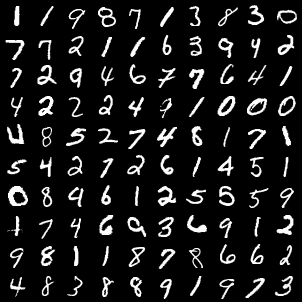

In [95]:
from IPython.display import Image
from torchvision.utils import save_image

# Save some real images

for images, _ in data_loader:
  images = images.reshape(images.size(0), 1, 28, 28)
  save_image(denorm(images), os.path.join(sample_dir, 'real_images.png'), nrow=10)
  break


Image(os.path.join(sample_dir, 'real_images.png'))

Saving fake_images-0000.png


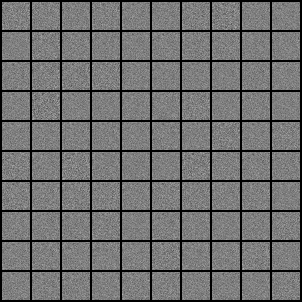

In [96]:
sample_vectors = torch.randn(batch_size, latent_size).to(device)


def save_fake_images(index):
  fake_images = G(sample_vectors)
  fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
  fake_fname = 'fake_images-{0:0=4d}.png'.format(index)
  print('Saving', fake_fname)
  save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=10)



# Before Training
save_fake_images(0)
Image(os.path.join(sample_dir, 'fake_images-0000.png'))

 # In each epoch, we train the discriminator first, and then the generator.

In [ ]:
%%time

num_epochs = 300
total_step = len(data_loader)
d_losses, g_losses, real_scores, fake_scores = [], [], [], []

for epoch in range(num_epochs):
  for i, (images, _) in enumerate(data_loader):
    # Load a batch & transform to vectors
    images = images.reshape(batch_size, -1).to(device)

    # Train the discriminator and generator
    d_loss, real_score, fake_score = train_discriminator(images)
    g_loss, fake_images = train_generator()

    # inspect the losses
    if (i+1)% 20 == 0:
      d_losses.append(d_loss.item())
      g_losses.append(g_loss.item())
      real_scores.append(real_score.mean().item())
      fake_scores.append(fake_score.mean().item())
      print('Epoch [{} / {}], Step [{} / {}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(z)): {:.2f}'
      .format(epoch, num_epochs, i+1, total_step, d_loss.item(), g_loss.item(), real_score.mean().item(),
              fake_score.mean().item()))

  # Sample and save images
  save_fake_images(epoch+1)

Epoch [0 / 300], Step [20 / 600], d_loss: 0.0917, g_loss: 5.5885, D(x): 0.97, D(G(z)): 0.03
Epoch [0 / 300], Step [40 / 600], d_loss: 0.1778, g_loss: 4.3338, D(x): 0.98, D(G(z)): 0.10
Epoch [0 / 300], Step [60 / 600], d_loss: 0.0876, g_loss: 8.4311, D(x): 0.96, D(G(z)): 0.01
Epoch [0 / 300], Step [80 / 600], d_loss: 0.0918, g_loss: 5.1582, D(x): 0.96, D(G(z)): 0.02
Epoch [0 / 300], Step [100 / 600], d_loss: 0.1315, g_loss: 4.1674, D(x): 0.96, D(G(z)): 0.05
Epoch [0 / 300], Step [120 / 600], d_loss: 0.0517, g_loss: 4.1300, D(x): 0.99, D(G(z)): 0.04
Epoch [0 / 300], Step [140 / 600], d_loss: 0.3285, g_loss: 4.3162, D(x): 0.90, D(G(z)): 0.02
Epoch [0 / 300], Step [160 / 600], d_loss: 0.1563, g_loss: 5.1183, D(x): 0.94, D(G(z)): 0.02
Epoch [0 / 300], Step [180 / 600], d_loss: 0.1316, g_loss: 4.7554, D(x): 0.93, D(G(z)): 0.02
Epoch [0 / 300], Step [200 / 600], d_loss: 0.1321, g_loss: 5.5636, D(x): 0.95, D(G(z)): 0.02
Epoch [0 / 300], Step [220 / 600], d_loss: 0.0790, g_loss: 6.4294, D(x): 0

In [ ]:
torch.save(G.state_dict(), 'G.ckpt')
torch.save(D.state_dict(), 'D.ckpt')